# Code Quality Prediction

The objective of this notebook is to develop a machine learning model for predicting whether a software module is defective, using standard code metrics.

Workflow:

- Data loading
- Exploratory Data Analysis
- Data cleaning
- Feature Engineering
- Baseline model
- LightGBM Model
- Cross validation
- Evaluation on eval data

The final model predicts code quality, which can be later integrated into automatic grading pipeline.

In [3]:
# importing libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


# Data loading

In [6]:
# loading the dataset

cm1 = pd.read_csv("../datasets/code-quality/cm1.csv")

In [7]:
# inspecting the dataset

cm1.head()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,1.30,1.30,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,2,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1,1,1,1,1.0,1.0,1.0,1.0,1.0,True
2,3,24.0,5.0,1.0,3.0,63.0,309.13,0.11,9.50,32.54,2936.77,0.10,163.15,1,0,6,0,15.0,15.0,44.0,19.0,9.0,False
3,4,20.0,4.0,4.0,2.0,47.0,215.49,0.06,16.00,13.47,3447.89,0.07,191.55,0,0,3,0,16.0,8.0,31.0,16.0,7.0,False
4,5,24.0,6.0,6.0,2.0,72.0,346.13,0.06,17.33,19.97,5999.58,0.12,333.31,0,0,3,0,16.0,12.0,46.0,26.0,11.0,False


In [9]:
cm1.shape

(498, 23)

In [10]:
cm1.columns

Index(['id', 'loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e',
       'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment',
       'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount',
       'defects'],
      dtype='str')

In [11]:
cm1.info()

<class 'pandas.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 498 non-null    int64  
 1   loc                498 non-null    float64
 2   v(g)               498 non-null    float64
 3   ev(g)              498 non-null    float64
 4   iv(g)              498 non-null    float64
 5   n                  498 non-null    float64
 6   v                  498 non-null    float64
 7   l                  498 non-null    float64
 8   d                  498 non-null    float64
 9   i                  498 non-null    float64
 10  e                  498 non-null    float64
 11  b                  498 non-null    float64
 12  t                  498 non-null    float64
 13  lOCode             498 non-null    int64  
 14  lOComment          498 non-null    int64  
 15  lOBlank            498 non-null    int64  
 16  locCodeAndComment  498 non-null    in

# EDA

In [12]:
cm1.describe().T

,count,mean,std,min,25%,50%,75%,max
id,498.0,249.500000,143.904482,1.0,125.2500,249.50,373.7500,498.00
loc,498.0,29.644779,42.753572,1.0,8.0000,17.00,31.0000,423.00
v(g),498.0,5.382329,8.347359,1.0,1.0000,3.00,6.0000,96.00
ev(g),498.0,2.490763,3.658847,1.0,1.0000,1.00,1.0000,30.00
iv(g),498.0,3.528916,5.464398,1.0,1.0000,2.00,4.0000,63.00
n,498.0,143.956426,221.049888,1.0,25.0000,67.50,151.7500,2075.00
v,498.0,900.175823,1690.814334,0.0,102.1900,329.82,861.4600,17124.28
l,498.0,0.146325,0.159337,0.0,0.0500,0.09,0.1775,1.30
d,498.0,15.829378,15.330960,0.0,5.6300,11.64,21.1425,125.77
i,498.0,38.455361,36.996297,0.0,16.2100,27.40,46.9000,293.68


# Data cleaning

In [13]:
cm1.isnull().sum().sort_values(ascending=False)

id                   0
t                    0
branchCount          0
total_Opnd           0
total_Op             0
uniq_Opnd            0
uniq_Op              0
locCodeAndComment    0
lOBlank              0
lOComment            0
lOCode               0
b                    0
loc                  0
e                    0
i                    0
d                    0
l                    0
v                    0
n                    0
iv(g)                0
ev(g)                0
v(g)                 0
defects              0
dtype: int64

In [15]:
print(cm1.isnull().sum().sum())

0


### Observation

The dataset has no missing values. So, no missing value treatment is required.

In [19]:
# target distribution

cm1["defects"].value_counts()

defects
False    449
True      49
Name: count, dtype: int64

### Observation

The dataset is highly imbalanced.

- Non-defective modules: 449 (90.2%)
- Defective modules: 49 (9.8%)

Due to this imbalance, accuracy alone is not an appropriate evaluation metric. Precision, Recall and F1-score will also be used to assess model performance.

In [23]:
# duplicate row check

print(cm1.duplicated().sum())

0


### Observation :

No duplicate values, no need to delete any duplicate rows.

# Feature Scaling

In [24]:
# lets drop the id column, not required for model building

cm1 = cm1.drop(columns=["id"])

The dataset already contains metrics such as cyclomatic complexity, LOC, Halstead metrics, and branch count. Hence, no additional feature engineering is required. Also, the id column is dropped as it is not a predictive value

In [31]:
# separating X and Y

X = cm1.drop(columns=["defects"])
y = cm1["defects"].astype(int)

In [32]:
# train, test, split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(398, 21)
(100, 21)
defects
0    359
1     39
Name: count, dtype: int64
defects
0    90
1    10
Name: count, dtype: int64


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Model

Using Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

baseline.fit(X_train_scaled, y_train)

baseline_pred = baseline.predict(X_test_scaled)

Evaluating Baseline model

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

baseline_prob = baseline.predict_proba(X_test_scaled)[:,1]

print("Accuracy :", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall   :", recall_score(y_test, baseline_pred))
print("F1 Score :", f1_score(y_test, baseline_pred))
print("ROC AUC  :", roc_auc_score(y_test, baseline_prob))

print(classification_report(y_test, baseline_pred))
print(confusion_matrix(y_test, baseline_pred))

Accuracy : 0.74
Precision: 0.19230769230769232
Recall   : 0.5
F1 Score : 0.2777777777777778
ROC AUC  : 0.6577777777777777
              precision    recall  f1-score   support

           0       0.93      0.77      0.84        90
           1       0.19      0.50      0.28        10

    accuracy                           0.74       100
   macro avg       0.56      0.63      0.56       100
weighted avg       0.86      0.74      0.79       100

[[69 21]
 [ 5  5]]


# LightGBM

In [36]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)
lgbm_prob = lgbm.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 39, number of negative: 359
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000334 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1345
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

Evaluating LightGBM

In [37]:
print("Accuracy :", accuracy_score(y_test, lgbm_pred))
print("Precision:", precision_score(y_test, lgbm_pred))
print("Recall   :", recall_score(y_test, lgbm_pred))
print("F1 Score :", f1_score(y_test, lgbm_pred))
print("ROC AUC  :", roc_auc_score(y_test, lgbm_prob))

print(classification_report(y_test, lgbm_pred))
print(confusion_matrix(y_test, lgbm_pred))

Accuracy : 0.88
Precision: 0.375
Recall   : 0.3
F1 Score : 0.3333333333333333
ROC AUC  : 0.6033333333333333
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        90
           1       0.38      0.30      0.33        10

    accuracy                           0.88       100
   macro avg       0.65      0.62      0.63       100
weighted avg       0.87      0.88      0.87       100

[[85  5]
 [ 7  3]]


Tuning LightGBM, works better for such datasets

In [45]:
# Tuned LightGBM Model
lgbm = LGBMClassifier(
    objective="binary",
    random_state=42,
    class_weight="balanced",
    learning_rate=0.03,
    n_estimators=500,
    num_leaves=15,
    max_depth=5,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    verbose=-1
)

In [46]:
# train
lgbm.fit(X_train, y_train)

,num_leaves,15
,max_depth,5
,learning_rate,0.03
,n_estimators,500
,objective,'binary'
,class_weight,'balanced'
,min_child_samples,10
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,0.1


In [47]:
# predicted probabilities
y_prob = lgbm.predict_proba(X_test)[:, 1]

In [48]:
# Custom threshold, lets check with 0.4
threshold = 0.4
y_pred = (y_prob >= threshold).astype(int)

Accuracy : 0.7800
Precision: 0.1667
Recall   : 0.3000
F1 Score : 0.2143
ROC AUC  : 0.6267

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        90
           1       0.17      0.30      0.21        10

    accuracy                           0.78       100
   macro avg       0.54      0.57      0.54       100
weighted avg       0.84      0.78      0.81       100


Confusion Matrix

[[75 15]
 [ 7  3]]


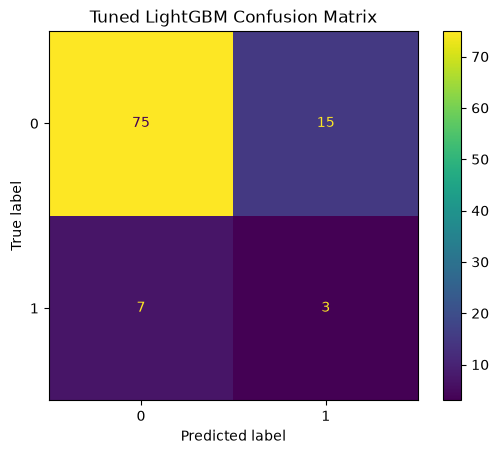

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

# Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

# Confusion Matrix Plot
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Tuned LightGBM Confusion Matrix")
plt.show()

In [53]:
# results are not as expected, infact lightgbm was better than tuned LightGBM, lets experiment with threshold.

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.1,0.68,0.107143,0.3,0.157895
1,0.2,0.72,0.125000,0.3,0.176471
2,0.3,0.74,0.136364,0.3,0.187500
3,0.4,0.78,0.166667,0.3,0.214286
4,0.5,0.80,0.187500,0.3,0.230769
5,0.6,0.85,0.272727,0.3,0.285714
6,0.7,0.85,0.272727,0.3,0.285714


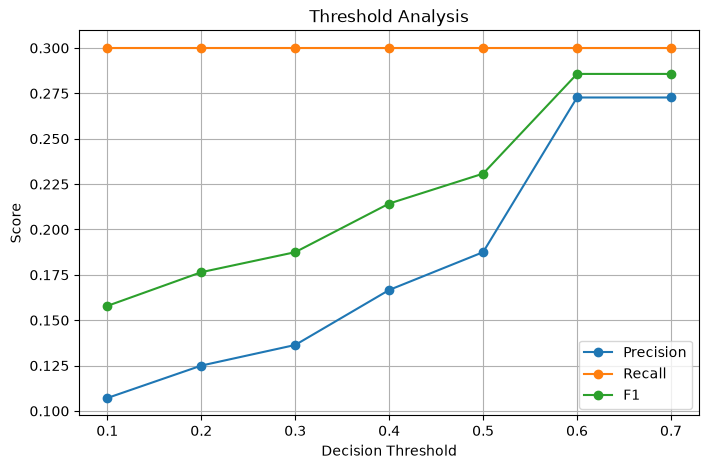

In [55]:
#plotting these metrics

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

### Observation :

This clearly proves that threshold is not the problem. Recall is low due to highly imbalanced dataset.

The optimal fix is to apply SMOTE on training dataset.

# SMOTE

In [68]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [69]:
# check imbalance

print(y_train.value_counts())

print(y_train_smote.value_counts())

defects
0    359
1     39
Name: count, dtype: int64
defects
0    359
1    359
Name: count, dtype: int64


In [70]:
# train LightBEAM on X_train_smote and Y_train_smote

from lightgbm import LGBMClassifier

lgbm_smote = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05
)

lgbm_smote.fit(X_train_smote, y_train_smote)

,learning_rate,0.05
,n_estimators,200
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [71]:
y_pred_smote = lgbm_smote.predict(X_test)
y_prob_smote = lgbm_smote.predict_proba(X_test)[:, 1]

In [72]:
# predictions

y_pred_smote = lgbm_smote.predict(X_test)

y_prob_smote = lgbm_smote.predict_proba(X_test)[:, 1]

In [73]:
# Evaluate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

print("Accuracy :", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall   :", recall_score(y_test, y_pred_smote))
print("F1 Score :", f1_score(y_test, y_pred_smote))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_smote))

print("\nClassification Report")
print(classification_report(y_test, y_pred_smote))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_smote))

Accuracy : 0.78
Precision: 0.16666666666666666
Recall   : 0.3
F1 Score : 0.21428571428571427
ROC AUC  : 0.6544444444444444

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        90
           1       0.17      0.30      0.21        10

    accuracy                           0.78       100
   macro avg       0.54      0.57      0.54       100
weighted avg       0.84      0.78      0.81       100


Confusion Matrix
[[75 15]
 [ 7  3]]


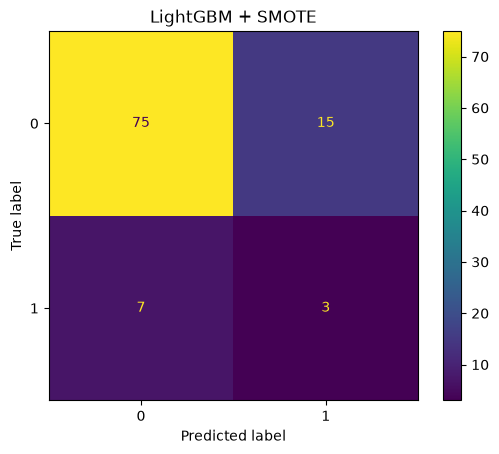

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote)

plt.title("LightGBM + SMOTE")
plt.show()

### Observation :

Even after using SMOTE, the results are not as expected. Lets experiment with XGBoost.

XGBoost

In [ ]:
# implementing XGBoost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=359/39,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

In [75]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [ ]:
# plotting metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy : 0.8100
Precision: 0.2000
Recall   : 0.3000
F1 Score : 0.2400
ROC AUC  : 0.6333

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.87      0.89        90
           1       0.20      0.30      0.24        10

    accuracy                           0.81       100
   macro avg       0.56      0.58      0.57       100
weighted avg       0.85      0.81      0.83       100


Confusion Matrix

[[78 12]
 [ 7  3]]


### Observation :

This confirms that LightBGM was better than XGBoost, lets try implementing RandomizedSearchCV on LightGBM

RandomizedSearchCV on LightGBM

In [78]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 3, 5, 7],
    "min_child_samples": [5, 10, 20, 30],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

lgbm = LGBMClassifier(
    random_state=42,
    class_weight="balanced"
)

search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 31, number of negative: 287
[LightGBM] [Info] Number of positive: 31, number of negative: 288
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1099
[LightGBM] [Info] Number of data points in the train set: 318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002860 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1128
[LightGBM] [Info] Number of data points in the train set: 319, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] S

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [-1, 3, ...], 'min_child_samples': [5, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whic

In [79]:
print(search.best_params_)
print(search.best_score_)

{'subsample': 0.7, 'num_leaves': 63, 'n_estimators': 100, 'min_child_samples': 30, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
0.39928104575163403


In [80]:
best_lgbm = search.best_estimator_

y_pred = best_lgbm.predict(X_test)
y_prob = best_lgbm.predict_proba(X_test)[:, 1]

In [82]:
y_pred_best = best_lgbm.predict(X_test)
y_prob_best = best_lgbm.predict_proba(X_test)[:, 1]

In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_best):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_best))

Accuracy : 0.7400
Precision: 0.1923
Recall   : 0.5000
F1 Score : 0.2778
ROC AUC  : 0.6544

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.77      0.84        90
           1       0.19      0.50      0.28        10

    accuracy                           0.74       100
   macro avg       0.56      0.63      0.56       100
weighted avg       0.86      0.74      0.79       100


Confusion Matrix

[[69 21]
 [ 5  5]]


Observation :

This was almost same as Logistic Regression. So, lets move on to implement 5-fold cross validation

# Cross Validation

In [84]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    lgbm,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print(scores)
print(scores.mean())

[0.11111111 0.375      0.26086957 0.11764706 0.44444444]
0.26181443591929526


## ROC Curve

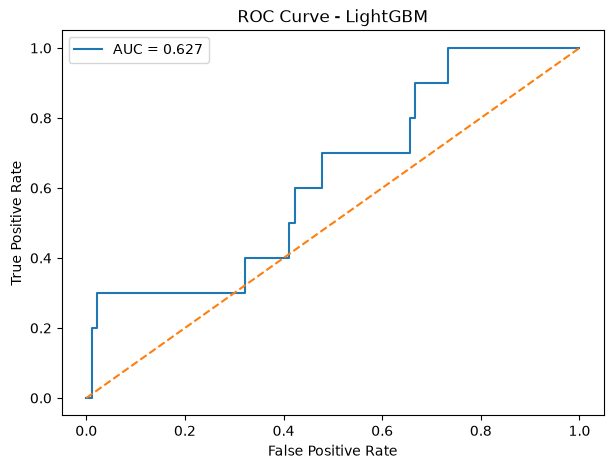

In [86]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    random_state=42,
    class_weight="balanced"
)

lgbm.fit(X_train, y_train)


# Probability predictions
y_prob = lgbm.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()

plt.show()

## Precision - Recall Curve

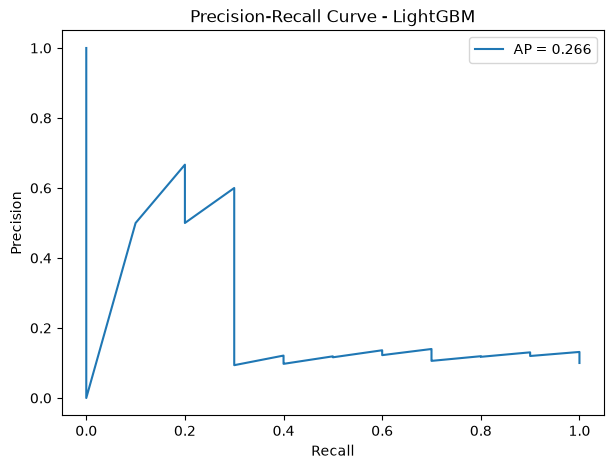

In [92]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(recall, precision, label=f"AP = {ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - LightGBM")
plt.legend()

plt.show()

# Save Model

In [93]:
import joblib

joblib.dump(lgbm, "../models/code_quality_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


# Feature Importance

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
13,lOComment,248
14,lOBlank,242
8,i,240
0,loc,155
12,lOCode,125
16,uniq_Op,124
7,d,122
4,n,118
1,v(g),106
5,v,99


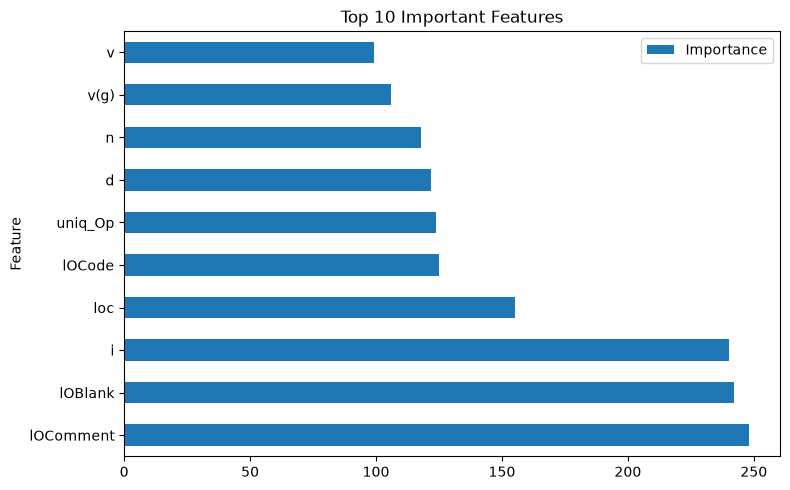

In [90]:
# plotting

importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

# Model Comparison

In [91]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM",
        "LightGBM + SMOTE",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, lgbm_pred),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, lgbm_pred),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, lgbm_pred),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, lgbm_pred),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, lgbm_prob),
        roc_auc_score(y_test, y_prob_smote),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

comparison.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,LightGBM,0.88,0.375000,0.3,0.333333,0.603333
0,Logistic Regression,0.74,0.192308,0.5,0.277778,0.657778
3,XGBoost,0.81,0.200000,0.3,0.240000,0.633333
2,LightGBM + SMOTE,0.78,0.166667,0.3,0.214286,0.654444


## Final Model Selection

Four models were evaluated.

Although Logistic Regression achieved higher recall, its precision and overall F1-score were significantly lower.

LightGBM achieved the highest F1-score while maintaining the best precision and overall accuracy.

SMOTE and XGBoost were also evaluated but did not outperform the original LightGBM model.

Therefore, LightGBM was selected as the final production model.